# Libraries Used & Loading Data

In [1]:
import pandas as pd

In [2]:
# Loading Data
src = '/content/marketing_data.csv'
df = pd.read_csv(src)

In [3]:
# Data Preview
df.head(5)

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Response,Complain,Country
0,1826,1970,Graduation,Divorced,84835.0,0,0,2014-06-16,0,189,...,6,1,0,0,0,0,0,1,0,Spain
1,1,1961,Graduation,Single,57091.0,0,0,2014-06-15,0,464,...,7,5,0,0,0,0,1,1,0,Canada
2,10476,1958,Graduation,Married,67267.0,0,1,2014-05-13,0,134,...,5,2,0,0,0,0,0,0,0,USA
3,1386,1967,Graduation,Together,32474.0,1,1,2014-05-11,0,10,...,2,7,0,0,0,0,0,0,0,Australia
4,5371,1989,Graduation,Single,21474.0,1,0,2014-04-08,0,6,...,2,7,1,0,0,0,0,1,0,Spain


# Data Cleaning & Wrangling

In [4]:
df_wrangling = df.copy()

In [5]:
# 1. Stripping column names
df_wrangling.columns = df_wrangling.columns.str.strip()

In [6]:
# 1. Dropping NA
df_wrangling = df_wrangling.dropna().reset_index(drop=True)

In [7]:
# 1. Change Date type
df_wrangling['Dt_Customer'] = pd.to_datetime(df_wrangling['Dt_Customer'])

In [8]:
# 2. Standardizing Categories
df_wrangling['Marital_Status'] = df_wrangling['Marital_Status'].replace(
    {'YOLO': 'Single', 'Alone': 'Single', 'Absurd': 'Single'}
)

df_wrangling['Education'] = df_wrangling['Education'].replace(
    {'2n Cycle': 'Master', 'Graduation': 'Bachelor'}
)

# Data Splitting

In [9]:
from sklearn.model_selection import train_test_split

In [10]:
# Data Splitting
X = df_wrangling.drop(columns=['Response'])
y = df_wrangling['Response']

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Data Preprocessing

In [12]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [13]:
# Outlier Fitting
outlier_columns = ['Year_Birth', 'Income']

# Fitting
capped_boundaries = {}
for col in outlier_columns:
  Q1 = X_train[col].quantile(0.25)
  Q3 = X_train[col].quantile(0.75)
  IQR = Q3 - Q1
  upper = Q3 + 1.5 * IQR
  lower = Q1 - 1.5 * IQR
  capped_boundaries[col] = (lower, upper)

# Transform
for col in outlier_columns:
  lower, upper = capped_boundaries[col]
  X_train[col] = X_train[col].clip(lower, upper)
  X_test[col] = X_test[col].clip(lower, upper)

In [14]:
# Feature Engineering
def feature_engineering(df_inp):
  df = df_inp.copy()
  # Better Demographic Profiling
  df['Age'] = 2014 - df['Year_Birth']
  # Total Household Dependencies
  df['Total_Children'] = df['Kidhome'] + df['Teenhome']
  # Total spending for KPI
  df['Total_Spent'] = (df['MntWines'] + df['MntFruits'] + df['MntMeatProducts'] +
                       df['MntFishProducts'] + df['MntSweetProducts'] + df['MntGoldProds'])

  # Overall marketing engagement
  df['Total_Accepted_Cmp'] = (df['AcceptedCmp1'] + df['AcceptedCmp2'] + df['AcceptedCmp3'] +
                              df['AcceptedCmp4'] + df['AcceptedCmp5'])
  df['Total_Accepted_Cmp'] = pd.to_numeric(df['Total_Accepted_Cmp'])

  return df

In [15]:
X_train = feature_engineering(X_train)
X_test = feature_engineering(X_test)

In [16]:
# Defining Features
redundant_cols = ['ID', 'Year_Birth', 'Dt_Customer',
                  'Kidhome', 'Teenhome',
                  'MntWines', 'MntFruits', 'MntMeatProducts',
                  'MntFishProducts', 'MntSweetProducts', 'MntGoldProds',
                  'AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4',
                  'AcceptedCmp5', 'Complain']
X_train.drop(columns=redundant_cols, inplace=True)
X_test.drop(columns=redundant_cols, inplace=True)

In [17]:
# Ordinal Encoding for Education
EDUCATION_ORDER = {
    'Basic': 0,
    'Bachelor': 1,
    'Master': 2,
    'PhD': 3
}
X_train['Education'] = X_train['Education'].map(EDUCATION_ORDER)
X_test['Education'] = X_test['Education'].map(EDUCATION_ORDER)

In [18]:
# One Hot Encoding
OHE_COLS = ['Marital_Status', 'Country']

encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
encoder.fit(X_train[OHE_COLS])

ohe_cols_names = encoder.get_feature_names_out(OHE_COLS)

X_train_ohe = pd.DataFrame(encoder.transform(X_train[OHE_COLS]), columns=ohe_cols_names, index=X_train.index)
X_test_ohe  = pd.DataFrame(encoder.transform(X_test[OHE_COLS]),  columns=ohe_cols_names, index=X_test.index)

X_train = X_train.drop(columns=OHE_COLS).join(X_train_ohe)
X_test  = X_test.drop(columns=OHE_COLS).join(X_test_ohe)

In [19]:
# Scaling
FEATURES = X_train.columns.to_list()

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Modelling

In [20]:
from sklearn.linear_model import LogisticRegression

In [21]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [22]:
y_pred = model.predict(X_test)

# Evaluation

In [23]:
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix,precision_score, recall_score,f1_score,roc_curve, roc_auc_score
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold, cross_val_score
import numpy as np

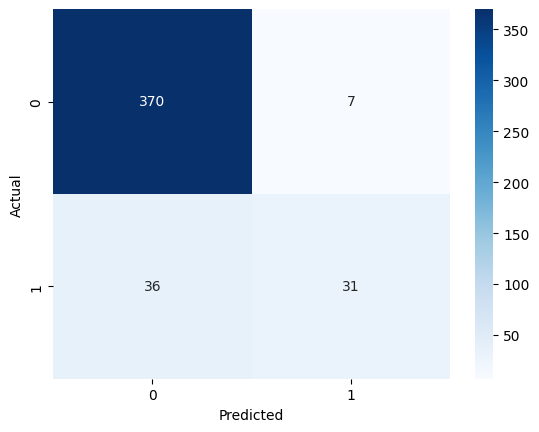

In [24]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

ROC-AUC: 0.8908


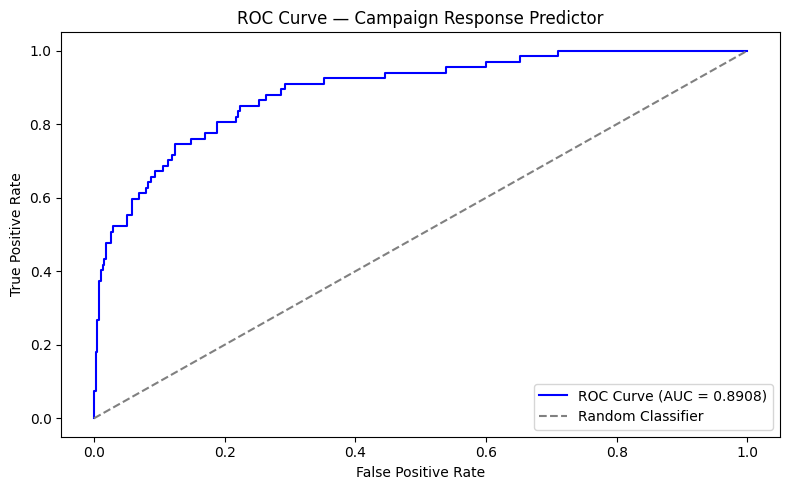

In [25]:
# ROC Curve
y_prob = model.predict_proba(X_test)[:, 1]

# compute ROC-AUC score
roc_auc = roc_auc_score(y_test, y_prob)
print(f'ROC-AUC: {roc_auc:.4f}')

# compute curve points
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# plot
plt.figure(figsize=(8, 5))
plt.plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Campaign Response Predictor')
plt.legend()
plt.tight_layout()
plt.show()

In [26]:
# Classification Report

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.91      0.98      0.95       377
           1       0.82      0.46      0.59        67

    accuracy                           0.90       444
   macro avg       0.86      0.72      0.77       444
weighted avg       0.90      0.90      0.89       444



In [28]:

# use StratifiedKFold to preserve the 15% response rate in each fold
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# run CV on the full dataset (combine train+test back together)
X_full = np.vstack([X_train, X_test])
y_full = pd.concat([y_train, y_test]).values

# evaluate with multiple metrics
auc_scores = cross_val_score(model, X_full, y_full, cv=cv, scoring='roc_auc')
f1_scores  = cross_val_score(model, X_full, y_full, cv=cv, scoring='f1')

print(f'ROC-AUC : {auc_scores.mean():.4f} ± {auc_scores.std():.4f}')
print(f'F1 Score: {f1_scores.mean():.4f} ± {f1_scores.std():.4f}')
print(f'\nPer-fold AUC: {np.round(auc_scores, 4)}')

ROC-AUC : 0.8661 ± 0.0225
F1 Score: 0.4920 ± 0.0799

Per-fold AUC: [0.8717 0.818  0.8595 0.8921 0.8897 0.8626 0.852  0.8461 0.8935 0.8759]


# Serialize for Streamlit

In [29]:
import joblib

In [30]:
joblib.dump(model, 'model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(encoder, 'encoder.pkl')
joblib.dump(capped_boundaries, 'cap_bounds.pkl')
joblib.dump(FEATURES, 'features.pkl')


['features.pkl']

In [31]:
artifacts = {
    'education_order': EDUCATION_ORDER,
    'redundant_cols': redundant_cols
}

joblib.dump(artifacts, 'artifacts.pkl')

['artifacts.pkl']